In [1]:
import pandas as pd
import matplotlib.pyplot as plt

BEHAVIORS_PATH = "../smallDataset/MINDsmall_train/behaviors.tsv"

# MIND behaviors.tsv has 5 tab-separated columns, no header in the file.
cols = ["impression_id", "user_id", "time", "history", "impressions"]
beh = pd.read_csv(BEHAVIORS_PATH, sep="\t", header=None, names=cols)

beh.head(), beh.shape

(   impression_id user_id                   time  \
 0              1  U13740  11/11/2019 9:05:58 AM   
 1              2  U91836  11/12/2019 6:11:30 PM   
 2              3  U73700  11/14/2019 7:01:48 AM   
 3              4  U34670  11/11/2019 5:28:05 AM   
 4              5   U8125  11/12/2019 4:11:21 PM   
 
                                              history  \
 0  N55189 N42782 N34694 N45794 N18445 N63302 N104...   
 1  N31739 N6072 N63045 N23979 N35656 N43353 N8129...   
 2  N10732 N25792 N7563 N21087 N41087 N5445 N60384...   
 3  N45729 N2203 N871 N53880 N41375 N43142 N33013 ...   
 4                        N10078 N56514 N14904 N33740   
 
                                          impressions  
 0                                  N55689-1 N35729-0  
 1  N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...  
 2  N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...  
 3                N35729-0 N33632-0 N49685-1 N27581-0  
 4  N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...  ,
 (156

# Interpretation of the table behaviours.tsv

1
U13740
11/11/2019 9:05:58 AM	
N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801	
N55689-1 N35729-0

* This is a typical row. Here we have the ImpressionID as 1 (Meaning the system showed this user a small set of candidate articles at this time), 

* U13740 as the user ID,
* Time as the timestamp (News is time-sensitive and we must avoid training on future clicks)
* N55189 all the way to N31801 are the articles the user previously clicked on before this impression
* The history length in this case is 9 and this is the user profile and is what we use for content-based methods
* N55689-1 and N35729-0 is the most important part, each is formatted as newsID - ClickLabel, with 1 meaning user clicked and 0 meaning user did not click



In [1]:
n_impressions = len(beh)
n_users = beh["user_id"].nunique()

print("Impressions:", n_impressions)
print("Unique users:", n_users)

NameError: name 'beh' is not defined

* The dataset contains 156965 impressions and an impression means: The recommender system showed a set of candidate news articles to a user at a specific time. There were 50000 users meaning that each user appears in about 3 impressions.

* IMPORTANT INSIGHT: This means the users are extremely sparse and many users appear only a few times. This makes user-based collaborative filtering more difficult, cold-start is common and content-based methods becomes important.

In [ ]:
beh["impression_size"] = beh["impressions"].apply(lambda x: len(x.split()))

print("Average candidates per impression:", beh["impression_size"].mean())

Average candidates per impression: 37.22768770107986


* Means each time the system recommended articles to a user, about 37 articles were shown. So each user gets about 37 article candidates and typically clicks on only 1 of them. This could be a baseline of 1/37.
* So if we use metrics like MRR, nDCG@5 and nDCG@10, means that rank 1 is perfect and 37 is the worst score.

In [ ]:
def parse_impressions(impr_str):
    """
    Returns (news_ids, labels) from 'N123-0 N456-1 ...'
    """
    if pd.isna(impr_str) or impr_str == "":
        return [], []
    parts = impr_str.split()
    news_ids = []
    labels = []
    for p in parts:
        # split from the right in case of unexpected dashes
        nid, lbl = p.rsplit("-", 1)
        news_ids.append(nid)
        labels.append(int(lbl))
    return news_ids, labels


def parse_history(hist_str):
    """
    Returns list of news ids from 'N12 N34 N56 ...'
    """
    if pd.isna(hist_str) or hist_str == "":
        return []
    return hist_str.split()


In [ ]:
parsed = beh["impressions"].apply(parse_impressions)
beh["cand_news"] = parsed.apply(lambda x: x[0])
beh["cand_labels"] = parsed.apply(lambda x: x[1])

beh["impression_size"] = beh["cand_news"].apply(len)
beh["n_clicks"] = beh["cand_labels"].apply(sum)

beh[["impressions", "impression_size", "n_clicks"]].head(10)

,impressions,impression_size,n_clicks
0,N55689-1 N35729-0,2,1
1,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,11,1
2,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,36,1
3,N35729-0 N33632-0 N49685-1 N27581-0,4,1
4,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,69,1
5,N21119-1 N53696-0 N33619-1 N25722-0 N2869-0,5,2
6,N51346-0 N33848-0 N15132-0 N10688-0 N6342-0 N6...,173,1
7,N7821-0 N24898-0 N12029-0 N13579-0 N42977-0 N3...,7,1
8,N51048-1 N64094-0 N13907-0 N39010-0,4,1
9,N53585-1 N55689-0,2,1


Here we have an overview of some select rows where we can see that each row represents a user that has been presented with various articles (impressions) and whether or not they clicked on any of them. Here we can see that some users get presented a list of articles and click on several. Others show that it's very sparse with 173 impressions and only 1 click

In [ ]:
total_clicks = beh["n_clicks"].sum()
total_candidates = beh["impression_size"].sum()

print("Total clicks:", total_clicks)
print("Total candidate items shown:", total_candidates)

Total clicks: 236344
Total candidate items shown: 5843444


The total number of times users clicked an article across all impressions and the total number of articles shown to users whether clicked or not

In [ ]:
ctr = total_clicks / total_candidates if total_candidates > 0 else float("nan")
print("CTR (clicks / shown candidates):", ctr)

CTR (clicks / shown candidates): 0.040446010948338


The click through rate means out of all the articles shown to users, only around 4% are clicked

This means that we should NOT use accuracy because if a model predicts "no click" for everything, it will get 96% accuracy which doesn't make sense. Emphasis on ranking metrics and ranking the top candidates via MRR, nDCG@5 and nDCG@10 and the training needs to learn to distinguish rare positives from many negatives.

In [ ]:
print(beh["impression_size"].describe())

count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impression_size, dtype: float64


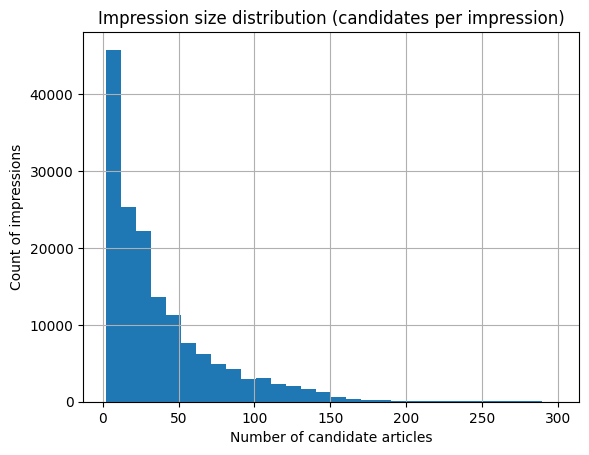

In [ ]:
beh["impression_size"].hist(bins=30)
plt.title("Impression size distribution (candidates per impression)")
plt.xlabel("Number of candidate articles")
plt.ylabel("Count of impressions")
plt.show()

We can observe here that the dataset is heavily skewed and that it varies from 2 article impressions for a user to up to 299 article impressions for a user

In [ ]:
one_click = (beh["n_clicks"] == 1).mean()
zero_click = (beh["n_clicks"] == 0).mean()
multi_click = (beh["n_clicks"] > 1).mean()

print("Fraction with 0 clicks:", zero_click)
print("Fraction with exactly 1 click:", one_click)
print("Fraction with >1 clicks:", multi_click)

print("Counts:")
print(beh["n_clicks"].value_counts().sort_index().head(10))

Fraction with 0 clicks: 0.0
Fraction with exactly 1 click: 0.7255630236039882
Fraction with >1 clicks: 0.27443697639601183
Counts:
n_clicks
1     113888
2      25571
3       9263
4       3975
5       1957
6        942
7        515
8        296
9        198
10       117
Name: count, dtype: int64


Here we can see that each article impression has had at least 1 click and there are no articles that haven't gotten at LEAST 1 click. We can also observe that it's skewed skewed as 72.5% of all article impressions have received precisely 1 click and at most have received 10 clicks.

While the majority of impressions contain a single click, a substantial number include multiple clicks, suggesting that the recommendation task is inherently multi-label. This reinforces the importance of ranking metrics such as nDCG, which account for multiple relevant items.

In [ ]:
beh["history_list"] = beh["history"].apply(parse_history)
beh["history_len"] = beh["history_list"].apply(len)

print(beh["history_len"].describe())
print()
print("Fraction with empty history:", (beh["history_len"] == 0).mean())

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_len, dtype: float64

Fraction with empty history: 0.02062880259930558


History = Articles the user clicked BEFORE a specific moment. Remember that an impression is one recommended event. Again, at this moment, a user is shown a list of candidate articles.

In [ ]:
beh["clicks"] = beh["impressions"].apply(
    lambda x: sum(int(i.split("-")[1]) for i in x.split())
)

print("Average clicks per impression:", beh["clicks"].mean())
print(beh["clicks"].value_counts().head())

Average clicks per impression: 1.5057114643391838
clicks
1    113888
2     25571
3      9263
4      3975
5      1957
Name: count, dtype: int64


count    50000.000000
mean         3.139300
std          3.001026
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         62.000000
Name: count, dtype: float64


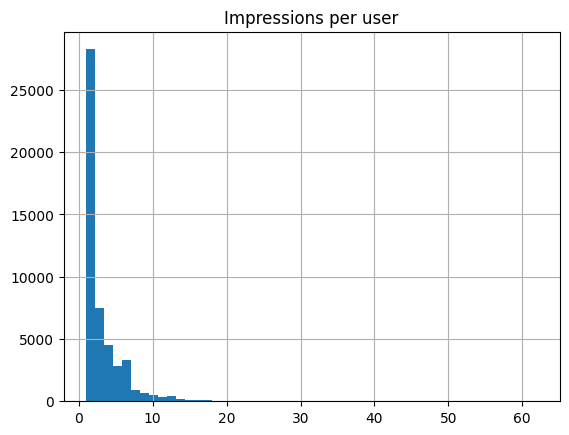

In [ ]:
user_counts = beh["user_id"].value_counts()

print(user_counts.describe())

user_counts.hist(bins=50)
plt.title("Impressions per user")
plt.show()

In [ ]:
beh["history_len"] = beh["history"].apply(
    lambda x: 0 if pd.isna(x) else len(x.split())
)

print(beh["history_len"].describe())

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_len, dtype: float64
